# Notebook 2 — Metrische XGBoost-Baseline (Case-Level, Stand C)

**Ziel:** Case-Level Metrik-Baseline für CloudAnoBench.  
Unterscheidung von `mali` gegenüber (`anom` + `norm`) direkt auf Case-Ebene.

**Stand C — Änderungen gegenüber Stand B:**
- XGBoost arbeitet direkt auf Case-Level-Features (1 Zeile pro Case, statt Zeitreihenzeilen)
- Pro Case: 5 universelle Metriken × 5 Aggregationen = **25 Features** (mean, max, std, p95, slope)
- Metrics-only, Log-only und Fusion sind damit auf gleicher Case-Level-Granularität vergleichbar

**Methodische Kernelemente:**
- Nur die 5 universellen Features (`cpu_usage`, `mem_usage`, `disk_io`, `net_in`, `net_out`) — Schema-Leakage-Prävention
- **Dreistufiger gruppenbasierter Split**: TrainVal/Test (gss1, rs=42) + Train/Val (gss2, rs=0)
- `scale_pos_weight`, Early Stopping und Threshold-Wahl **ausschließlich auf Train/Val**
- **Testset** dient ausschließlich der finalen Evaluation — keine Optimierung, kein Tuning
- Schwellenwertwahl: höchster Threshold mit `Recall_mali ≥ 0.95` (auf **Validation**)

**Input:** `data/processed/*.parquet` aus Notebook 1  
**Output:** `docs/split_assignments.csv`, `docs/split_distribution.csv`,
`docs/metric_case_features.csv`, `docs/metric_case_val_scores.csv`,
`docs/metric_case_test_scores.csv`, `docs/metric_case_results.csv`,
`docs/threshold_sensitivity_metric.csv`, `docs/feature_importance_baseline.png`, `docs/pr_curve_baseline.png`

In [1]:
import pandas as pd
import os
import json
import numpy as np
from scipy.stats import linregress
from xgboost import XGBClassifier, plot_importance
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    recall_score, confusion_matrix, precision_recall_curve,
    average_precision_score, f1_score, precision_score
)
import time
import matplotlib.pyplot as plt

base_path      = os.path.join(os.getcwd(), "..", "data")
processed_path = os.path.join(base_path, "processed")
docs_path      = os.path.join(os.getcwd(), "..", "docs")
os.makedirs(docs_path, exist_ok=True)

mali_clean = pd.read_parquet(os.path.join(processed_path, "mali_clean.parquet"))
anom_clean = pd.read_parquet(os.path.join(processed_path, "anom_clean.parquet"))
norm_clean = pd.read_parquet(os.path.join(processed_path, "norm_clean.parquet"))

print(mali_clean.shape, anom_clean.shape, norm_clean.shape)

(19384, 39) (41400, 39) (51208, 39)


In [2]:
# ─── Alle drei kombinieren ────────────────────────────────────────────────────
all_data = pd.concat([mali_clean, anom_clean, norm_clean], ignore_index=True)
all_data['group_id'] = all_data['dataset_type'] + '_' + all_data['scenario_id'].astype(str)

UNIVERSAL_METRICS = ['cpu_usage', 'mem_usage', 'disk_io', 'net_in', 'net_out']
META_COLS = ['case_id', 'dataset_type', 'scenario_id', 'group_id', 'label']

# ─── Leakage-freie Zeilenimputation mit globalen Train-Medianen ───────────────
# Reihenfolge: Split-Zuordnung laden → Trainingszeilen identifizieren →
# globale Mediane aus Trainingszeilen aller dataset_types → auf alle Splits anwenden.
# Kein dataset_type-bedingter Median: derselbe Wert für mali, anom, norm.

_split_df = pd.read_csv(os.path.join(docs_path, "split_assignments.csv"))
_train_case_ids = set(_split_df[_split_df['split'] == 'train']['case_id'])
_train_mask = all_data['case_id'].isin(_train_case_ids)

assert _train_mask.sum() > 0, "Keine Trainingszeilen gefunden — split_assignments.csv prüfen!"

row_level_medians = {}
for m in UNIVERSAL_METRICS:
    train_vals = all_data.loc[_train_mask, m]
    row_level_medians[m] = float(train_vals.median())

# Imputation: identischer globaler Median je Feature für alle dataset_types und Splits
nan_before = {m: int(all_data[m].isnull().sum()) for m in UNIVERSAL_METRICS}
for m in UNIVERSAL_METRICS:
    if all_data[m].isnull().any():
        all_data[m] = all_data[m].fillna(row_level_medians[m])
nan_after_total = all_data[UNIVERSAL_METRICS].isnull().sum().sum()

assert nan_after_total == 0, f"Noch {nan_after_total} NaN nach Zeilenimputation!"

# Sicherstellung: Mediane sind dataset_type-unabhängig (gleicher Wert für alle Typen)
for m in UNIVERSAL_METRICS:
    for dt in ['mali', 'anom', 'norm']:
        subset_nan = all_data.loc[all_data['dataset_type'] == dt, m].isnull().sum()
        assert subset_nan == 0, f"NaN in {m} für {dt} nach Imputation!"

print("Globale Train-Zeilenmediane (für alle dataset_types und Splits identisch):")
for m, v in row_level_medians.items():
    print(f"  {m}: {v:.6f}  (NaN vor Imputation: {nan_before[m]})")

# Artefakt speichern (gitignored unter data/)
with open(os.path.join(processed_path, "train_medians.json"), "w") as _f:
    json.dump({"row_level_medians": row_level_medians,
               "source": "Trainingszeilen aller drei dataset_types (mali+anom+norm)",
               "nan_imputed": nan_before}, _f, indent=2)
print("\n✓ Zeilenmediane gespeichert: data/processed/train_medians.json")

# ─── Slope-Hilfsfunktion (scipy.stats.linregress) ─────────────────────────────
def _slope(s):
    """Lineare Steigung der Zeitreihe. Gibt NaN zurueck wenn < 3 Werte."""
    v = s.dropna().values
    if len(v) < 3:
        return np.nan
    return float(linregress(np.arange(len(v), dtype=float), v).slope)

# ─── Case-Level-Feature-Aggregation ───────────────────────────────────────────
# 5 Metriken x 5 Aggregationen = 25 Features pro Case
# Input: zeilen-imputiertes all_data (kein NaN in UNIVERSAL_METRICS)
# Jede Aggregation erfasst einen anderen Aspekt der Metrik-Zeitreihe:
#   mean  → mittleres Lastniveau
#   max   → Spitzenwert (ein Peak genuegt)
#   std   → Variabilitaet (NaN wenn nur 1 Zeile im Case)
#   p95   → robuster Spitzenwert (Ausreisser-resistent)
#   slope → zeitlicher Trend (NaN wenn < 3 Zeilen im Case)
meta_df = (
    all_data[META_COLS]
    .drop_duplicates(subset='case_id')
    .reset_index(drop=True)
)

feature_parts = []
for m in UNIVERSAL_METRICS:
    grp = all_data.groupby('case_id')[m]
    part = pd.DataFrame({
        f'{m}_mean':  grp.mean(),
        f'{m}_max':   grp.max(),
        f'{m}_std':   grp.std(ddof=1),
        f'{m}_p95':   grp.quantile(0.95),
        f'{m}_slope': grp.apply(_slope),
    })
    feature_parts.append(part)

feat_df = pd.concat(feature_parts, axis=1).reset_index()
case_features = meta_df.merge(feat_df, on='case_id')

FEATURE_COLS = [c for c in case_features.columns if c not in META_COLS]

print(f"\nCases gesamt:      {len(case_features)}")
print(f"Features pro Case: {len(FEATURE_COLS)}")  # soll 25 sein
print(f"Feature-Spalten:   {FEATURE_COLS}")
print(f"NaN in Features:   {case_features[FEATURE_COLS].isnull().sum().sum()}")
nan_detail = case_features[FEATURE_COLS].isnull().sum()
if nan_detail.sum() > 0:
    print("NaN-Detail (vor Case-Level-Imputation):", nan_detail[nan_detail > 0].to_dict())
print(f"\nKlassenverteilung: mali={int((case_features['label']==1).sum())}, "
      f"negativ={int((case_features['label']==0).sum())}")

Globale Train-Zeilenmediane (für alle dataset_types und Splits identisch):
  cpu_usage: 19.740000  (NaN vor Imputation: 909)
  mem_usage: 43.050000  (NaN vor Imputation: 999)
  disk_io: 27.600000  (NaN vor Imputation: 1000)
  net_in: 1.019399  (NaN vor Imputation: 1269)
  net_out: 1.090000  (NaN vor Imputation: 1270)

✓ Zeilenmediane gespeichert: data/processed/train_medians.json



Cases gesamt:      1252
Features pro Case: 25
Feature-Spalten:   ['cpu_usage_mean', 'cpu_usage_max', 'cpu_usage_std', 'cpu_usage_p95', 'cpu_usage_slope', 'mem_usage_mean', 'mem_usage_max', 'mem_usage_std', 'mem_usage_p95', 'mem_usage_slope', 'disk_io_mean', 'disk_io_max', 'disk_io_std', 'disk_io_p95', 'disk_io_slope', 'net_in_mean', 'net_in_max', 'net_in_std', 'net_in_p95', 'net_in_slope', 'net_out_mean', 'net_out_max', 'net_out_std', 'net_out_p95', 'net_out_slope']
NaN in Features:   0

Klassenverteilung: mali=223, negativ=1029


In [3]:
# ─── Case-Level-Split ─────────────────────────────────────────────────────────
# GroupShuffleSplit auf Case-Ebene: 1252 Cases, 45 Gruppen.
# Gleiche Seeds wie Stand B (gss1 rs=42, gss2 rs=0) → identische Gruppen-Zuweisung.
# GroupShuffleSplit teilt nach unique groups, unabhaengig von der Zeilenzahl.

X_case = case_features[FEATURE_COLS]
y_case = case_features['label']
groups = case_features['group_id']

# ─── Split 1: TrainVal / Test (test_size=0.20, random_state=42) ───────────────
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
trainval_idx, test_idx = next(gss1.split(X_case, y_case, groups))

X_trainval      = X_case.iloc[trainval_idx]
y_trainval      = y_case.iloc[trainval_idx]
groups_trainval = groups.iloc[trainval_idx]

# ─── Split 2: Train / Val (innerhalb TrainVal) ────────────────────────────────
SEED_CANDIDATES = (0, 1, 2, 7, 42)
VAL_MIN_POS     = 10

def _pick_val_seed(X_tv, y_tv, groups_tv, seed_candidates, min_pos):
    """Waehlt Seed mit Val >= min_pos positiven Cases — kein Test-Zugriff."""
    for seed in seed_candidates:
        gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=seed)
        tr_idx, vl_idx = next(gss.split(X_tv, y_tv, groups_tv))
        if y_tv.iloc[vl_idx].sum() >= min_pos:
            return seed, tr_idx, vl_idx
    raise ValueError(f"Kein Seed in {seed_candidates} liefert Val >= {min_pos} positive Cases.")

val_seed, train_sub_idx, val_sub_idx = _pick_val_seed(
    X_trainval, y_trainval, groups_trainval, SEED_CANDIDATES, VAL_MIN_POS
)
print(f"Gewahlter Val-Seed: {val_seed}  (erste aus {SEED_CANDIDATES} mit Val-Pos >= {VAL_MIN_POS})")

X_train      = X_trainval.iloc[train_sub_idx]
X_val        = X_trainval.iloc[val_sub_idx]
y_train      = y_trainval.iloc[train_sub_idx]
y_val        = y_trainval.iloc[val_sub_idx]
groups_train = groups_trainval.iloc[train_sub_idx]
groups_val   = groups_trainval.iloc[val_sub_idx]

# Case-Metadaten fuer Auswertung
case_train = case_features.iloc[trainval_idx[train_sub_idx]].reset_index(drop=True)
case_val   = case_features.iloc[trainval_idx[val_sub_idx]].reset_index(drop=True)
case_test  = case_features.iloc[test_idx].reset_index(drop=True)
X_test     = case_test[FEATURE_COLS]
y_test     = case_test['label']

# ─── scale_pos_weight ausschliesslich aus Train ───────────────────────────────
neg = int((y_train == 0).sum())
pos = int((y_train == 1).sum())
scale_pos_weight = neg / pos

print(f"Train:       {len(case_train)} Cases  | mali={pos}, negativ={neg}  => scale_pos_weight: {scale_pos_weight:.4f}")
print(f"Validation:  {len(case_val)} Cases   | mali={int(y_val.sum())}, negativ={int((y_val==0).sum())}")
print(f"Test:        {len(case_test)} Cases   | mali={int((case_test['label']==1).sum())}, negativ={int((case_test['label']==0).sum())}")
print(f"\nTrain-Gruppen: {groups_train.nunique()}")
print(f"Val-Gruppen:   {groups_val.nunique()}")
print(f"Test-Gruppen:  {groups.iloc[test_idx].nunique()}")

# ─── Gruppen-Disjunktheit sicherstellen ──────────────────────────────────────
_g_tr  = set(groups_train)
_g_val = set(groups_val)
_g_te  = set(groups.iloc[test_idx])
assert len(_g_tr & _g_val) == 0, "Leakage: Gruppen in Train und Val!"
assert len(_g_val & _g_te) == 0, "Leakage: Gruppen in Val und Test!"
assert len(_g_tr  & _g_te) == 0, "Leakage: Gruppen in Train und Test!"
print("\u2713 Train / Val / Test sind gruppen-disjunkt.")

# ─── split_assignments.csv ────────────────────────────────────────────────────
def _assign_split(gid):
    if gid in _g_tr:  return 'train'
    if gid in _g_val: return 'val'
    if gid in _g_te:  return 'test'
    return 'unknown'

case_features_with_split = case_features.copy()
case_features_with_split['split'] = case_features_with_split['group_id'].apply(_assign_split)

split_assign = case_features_with_split[
    ['case_id', 'dataset_type', 'scenario_id', 'group_id', 'label', 'split']
].copy()
split_assign.to_csv(os.path.join(docs_path, "split_assignments.csv"), index=False)
print(f"\n\u2713 split_assignments.csv gespeichert ({len(split_assign)} Cases)")
print(split_assign['split'].value_counts().sort_index().to_string())

# ─── split_distribution.csv ───────────────────────────────────────────────────
dist_rows = []
for s in ['train', 'val', 'test']:
    sub = case_features_with_split[case_features_with_split['split'] == s]
    n_mali = int((sub['dataset_type'] == 'mali').sum())
    n_anom = int((sub['dataset_type'] == 'anom').sum())
    n_norm = int((sub['dataset_type'] == 'norm').sum())
    dist_rows.append({
        'split':    s,
        'n_total':  len(sub),
        'n_mali':   n_mali,
        'n_anom':   n_anom,
        'n_norm':   n_norm,
        'n_groups': int(sub['group_id'].nunique()),
        'pct_mali': round(n_mali / len(sub) * 100, 1),
    })
split_dist_df = pd.DataFrame(dist_rows)
split_dist_df.to_csv(os.path.join(docs_path, "split_distribution.csv"), index=False)
print(f"\n\u2713 split_distribution.csv gespeichert")
print(split_dist_df.to_string(index=False))

# ─── metric_case_features.csv ────────────────────────────────────────────────
case_features_with_split.to_csv(os.path.join(docs_path, "metric_case_features.csv"), index=False)
n_feat = len(case_features_with_split.columns)
print(f"\n\u2713 metric_case_features.csv gespeichert ({len(case_features_with_split)} Cases x {n_feat} Spalten)")

Gewahlter Val-Seed: 0  (erste aus (0, 1, 2, 7, 42) mit Val-Pos >= 10)
Train:       793 Cases  | mali=122, negativ=671  => scale_pos_weight: 5.5000
Validation:  206 Cases   | mali=53, negativ=153
Test:        253 Cases   | mali=48, negativ=205

Train-Gruppen: 28
Val-Gruppen:   8
Test-Gruppen:  9
✓ Train / Val / Test sind gruppen-disjunkt.

✓ split_assignments.csv gespeichert (1252 Cases)
split
test     253
train    793
val      206

✓ split_distribution.csv gespeichert
split  n_total  n_mali  n_anom  n_norm  n_groups  pct_mali
train      793     122     326     345        28      15.4
  val      206      53      58      95         8      25.7
 test      253      48      76     129         9      19.0

✓ metric_case_features.csv gespeichert (1252 Cases x 31 Spalten)


## Methodische Stärke: Case-Level dreistufige Aufteilung

| Split | Zweck |
|---|---|
| **Train** | XGBoost-Training, `scale_pos_weight`-Berechnung, Imputation-Mediane |
| **Validation** | Early Stopping (`eval_set`), Threshold-Wahl (Recall ≥ 0.95) |
| **Test** | Ausschließlich finale Evaluation — keine Optimierung, kein Tuning |

**Stand C — Case-Level-Granularität:**  
Alle drei Komponenten (Metrics-only, Log-only, Fusion) evaluieren auf Case-Ebene.  
XGBoost arbeitet direkt auf 25 aggregierten Features pro Case (5 Metriken × 5 Aggregationen).  
Dadurch sind alle Modelle auf gleicher Granularität vergleichbar — kein row-/case-level-Mischung.

Der `GroupShuffleSplit` verhindert Gruppen-Überschneidungen.  
Der Val-Seed wird ausschließlich anhand der TrainVal-Klassenverteilung geprüft — kein Test-Zugriff.

In [4]:
# ─── Case-Level-Feature-Imputation: fit nur auf X_train ──────────────────────
# NaN entstehen bei std (Case mit nur 1 Zeile) oder slope (Case mit < 3 Zeilen).
# Diese Case-Level-Mediane werden ausschließlich aus X_train berechnet und auf
# Val/Test angewendet. Dies ist die zweite Imputationsstufe (erste: Zeilenebene, oben).
# Dokumentation: train_medians.json enthält bereits die Zeilenmediane.

case_feature_medians = X_train.median()

# Prüfen ob Case-Level-NaN vorkommen
nan_case_train = X_train.isnull().sum().sum()
nan_case_val   = X_val.isnull().sum().sum()
nan_case_test  = X_test.isnull().sum().sum()
if nan_case_train + nan_case_val + nan_case_test > 0:
    print("Case-Level-NaN (vor Imputation):")
    print("  Train:", nan_case_train, "  Val:", nan_case_val, "  Test:", nan_case_test)
    nan_cols = X_train.isnull().sum()
    print("  NaN-Detail (X_train):", nan_cols[nan_cols > 0].to_dict())

    # Ergänzende Case-Level-Mediane aus X_train in train_medians.json ergänzen
    _existing = json.loads(open(os.path.join(processed_path, "train_medians.json")).read())
    _existing["case_feature_medians"] = {
        col: float(v) for col, v in case_feature_medians.items() if pd.notna(v)
    }
    with open(os.path.join(processed_path, "train_medians.json"), "w") as _f:
        json.dump(_existing, _f, indent=2)
    print("  \u2192 Case-Level-Mediane in train_medians.json erg\u00e4nzt.")

def _impute(X_df, medians):
    X_imp = X_df.copy()
    for col in X_imp.columns:
        if X_imp[col].isnull().any():
            X_imp[col] = X_imp[col].fillna(medians[col])
    return X_imp

X_train_imp = _impute(X_train, case_feature_medians)
X_val_imp   = _impute(X_val,   case_feature_medians)
X_test_imp  = _impute(X_test,  case_feature_medians)

nan_train = X_train_imp.isnull().sum().sum()
nan_val   = X_val_imp.isnull().sum().sum()
nan_test  = X_test_imp.isnull().sum().sum()
print(f"NaN nach Case-Level-Imputation \u2014 Train: {nan_train}, Val: {nan_val}, Test: {nan_test}")
assert nan_train == 0 and nan_val == 0 and nan_test == 0, "NaN nach Imputation!"
print("\u2713 Imputation abgeschlossen (X_train-Mediane auf Val/Test angewendet, kein Leakage)")

NaN nach Case-Level-Imputation — Train: 0, Val: 0, Test: 0
✓ Imputation abgeschlossen (X_train-Mediane auf Val/Test angewendet, kein Leakage)


In [5]:
# ─── Phase 4: Schutzprüfungen vor Modelltraining ─────────────────────────────
# Stoppt bei jeder Abweichung von den invarianten Anforderungen.

# 1. split_assignments.csv unverändert (Hash-Prüfung)
import hashlib
_split_path = os.path.join(docs_path, "split_assignments.csv")
with open(_split_path, "rb") as _fh:
    _split_hash = hashlib.sha256(_fh.read()).hexdigest()
print(f"split_assignments.csv SHA-256: {_split_hash[:16]}...")

# 2. Splitgrößen
_sa = pd.read_csv(_split_path)
_n_train = int((_sa['split'] == 'train').sum())
_n_val   = int((_sa['split'] == 'val').sum())
_n_test  = int((_sa['split'] == 'test').sum())
assert _n_train == 793, f"Erwartet 793 Train-Cases, gefunden: {_n_train}"
assert _n_val   == 206, f"Erwartet 206 Val-Cases, gefunden: {_n_val}"
assert _n_test  == 253, f"Erwartet 253 Test-Cases, gefunden: {_n_test}"
print(f"✓ Splitgrößen: Train={_n_train}, Val={_n_val}, Test={_n_test}")

# 3. Test-Subgruppen
_test_df = _sa[_sa['split'] == 'test']
_n_mali_test = int((_test_df['dataset_type'] == 'mali').sum())
_n_anom_test = int((_test_df['dataset_type'] == 'anom').sum())
_n_norm_test = int((_test_df['dataset_type'] == 'norm').sum())
assert _n_mali_test == 48,  f"Test mali erwartet 48, gefunden: {_n_mali_test}"
assert _n_anom_test == 76,  f"Test anom erwartet 76, gefunden: {_n_anom_test}"
assert _n_norm_test == 129, f"Test norm erwartet 129, gefunden: {_n_norm_test}"
print(f"✓ Test-Subgruppen: mali={_n_mali_test}, anom={_n_anom_test}, norm={_n_norm_test}")

# 4. Keine Case-ID in mehreren Splits
_case_split_counts = _sa.groupby('case_id')['split'].nunique()
assert (_case_split_counts > 1).sum() == 0, "Case-IDs in mehreren Splits!"
print(f"✓ Alle {len(_sa)} Cases genau einem Split zugeordnet")

# 5. Keine group_id in mehreren Splits
_group_split_counts = _sa.groupby('group_id')['split'].nunique()
assert (_group_split_counts > 1).sum() == 0, "group_ids in mehreren Splits!"
print(f"✓ Alle {_sa['group_id'].nunique()} Gruppen genau einem Split zugeordnet")

# 6. Imputationsmediane nur aus Trainingsfällen
_medians_file = json.loads(open(os.path.join(processed_path, "train_medians.json")).read())
_row_medians = _medians_file["row_level_medians"]
# Verifiziere: Median berechnet aus train-Zeilen stimmt mit gespeichertem überein
for m in UNIVERSAL_METRICS:
    _recomputed = float(all_data.loc[all_data['case_id'].isin(_train_case_ids), m].median())
    assert abs(_recomputed - _row_medians[m]) < 1e-9, \
        f"Median für {m} stimmt nicht überein: gespeichert={_row_medians[m]}, neu={_recomputed}"
print(f"✓ Zeilenmediane aus Trainingszeilen verifiziert")

# 7. Identische Mediane für mali, anom und norm (dataset_type-Unabhängigkeit)
for m in UNIVERSAL_METRICS:
    for dt in ['mali', 'anom', 'norm']:
        assert all_data.loc[all_data['dataset_type'] == dt, m].isnull().sum() == 0, \
            f"NaN in {m} für {dt} — Imputation fehlgeschlagen!"
print(f"✓ Einheitliche Mediane: kein dataset_type-bedingter Unterschied")

# 8. Keine NaN in den finalen 25 Features
assert X_train_imp.isnull().sum().sum() == 0, "NaN in X_train_imp!"
assert X_val_imp.isnull().sum().sum()   == 0, "NaN in X_val_imp!"
assert X_test_imp.isnull().sum().sum()  == 0, "NaN in X_test_imp!"
print(f"✓ Keine NaN in X_train_imp, X_val_imp, X_test_imp (je 25 Features)")

print("\n✓ Alle Schutzprüfungen bestanden — Training kann beginnen.")

split_assignments.csv SHA-256: 74ab884191cb2dc5...
✓ Splitgrößen: Train=793, Val=206, Test=253
✓ Test-Subgruppen: mali=48, anom=76, norm=129
✓ Alle 1252 Cases genau einem Split zugeordnet
✓ Alle 45 Gruppen genau einem Split zugeordnet


✓ Zeilenmediane aus Trainingszeilen verifiziert
✓ Einheitliche Mediane: kein dataset_type-bedingter Unterschied
✓ Keine NaN in X_train_imp, X_val_imp, X_test_imp (je 25 Features)

✓ Alle Schutzprüfungen bestanden — Training kann beginnen.


In [6]:
# ─── XGBoost-Training auf Case-Level ─────────────────────────────────────────
# Training ausschliesslich auf Train-Cases (793 Cases, 25 Features).
# eval_set = Validation (206 Cases) fuer Early Stopping.
# Kein Testset-Zugriff.

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    tree_method='hist',
    eval_metric='aucpr',
    early_stopping_rounds=20,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train_imp, y_train,
    eval_set=[(X_val_imp, y_val)],
    verbose=50
)
print("\nTraining abgeschlossen.")
print(f"Best Iteration: {model.best_iteration}")

[0]	validation_0-aucpr:0.32110


[49]	validation_0-aucpr:0.51745



Training abgeschlossen.
Best Iteration: 29


In [7]:
# ─── Threshold-Wahl auf Validation (Case-Level) ───────────────────────────────
# Testset wird hier nicht beruehrt.
y_proba_val = model.predict_proba(X_val_imp)[:, 1]
_, recalls_val, thresholds_val = precision_recall_curve(y_val, y_proba_val)
ap_val = average_precision_score(y_val, y_proba_val)

valid_thr_val = thresholds_val[recalls_val[:-1] >= 0.95]
best_threshold_val = float(valid_thr_val.max()) if len(valid_thr_val) > 0 else float(thresholds_val[0])

val_recall_at_thr = recall_score(y_val, (y_proba_val >= best_threshold_val).astype(int))
print(f"Validation AP:               {ap_val:.4f}")
print(f"Threshold (Val, Rec>=0.95):  {best_threshold_val:.6f}")
print(f"Val-Recall @ Threshold:      {val_recall_at_thr:.4f}")

# ─── Finale Evaluation auf Testset (Case-Level) ───────────────────────────────
t0 = time.time()
y_proba_test = model.predict_proba(X_test_imp)[:, 1]
latency_ms = (time.time() - t0) * 1000

_, recalls_test, thresholds_test = precision_recall_curve(y_test, y_proba_test)
ap_test = average_precision_score(y_test, y_proba_test)

y_pred_test = (y_proba_test >= best_threshold_val).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()

recall_test  = recall_score(y_test, y_pred_test)
prec_test    = tp / (tp + fp) if (tp + fp) > 0 else 0.0
f1_test      = f1_score(y_test, y_pred_test, zero_division=0)
fpr_total    = fp / (fp + tn) if (fp + tn) > 0 else 0.0

# FPR getrennt nach dataset_type (Case-Ebene)
anom_mask = (case_test['dataset_type'] == 'anom').values
norm_mask = (case_test['dataset_type'] == 'norm').values

fp_anom = int(((y_pred_test == 1) & (y_test.values == 0) & anom_mask).sum())
tn_anom = int(((y_pred_test == 0) & (y_test.values == 0) & anom_mask).sum())
fpr_anom = fp_anom / (fp_anom + tn_anom) if (fp_anom + tn_anom) > 0 else 0.0

fp_norm = int(((y_pred_test == 1) & (y_test.values == 0) & norm_mask).sum())
tn_norm = int(((y_pred_test == 0) & (y_test.values == 0) & norm_mask).sum())
fpr_norm = fp_norm / (fp_norm + tn_norm) if (fp_norm + tn_norm) > 0 else 0.0

print(f"\n=== Finale Test-Evaluation Case-Level (Threshold aus Validation) ===")
print(f"AP (Average Precision):      {ap_test:.4f}")
print(f"Threshold (aus Val):         {best_threshold_val:.6f}")
print(f"Test-Recall_mali:            {recall_test:.4f}")
print(f"Test-Precision:              {prec_test:.4f}")
print(f"Test-F1:                     {f1_test:.4f}")
print(f"Test-FPR_total:              {fpr_total:.4f}  ({fp} FP von {fp+tn} negativen Cases)")
print(f"Test-FPR_anom:               {fpr_anom:.4f}  ({fp_anom} FP von {fp_anom+tn_anom} anom Cases)")
print(f"Test-FPR_norm:               {fpr_norm:.4f}  ({fp_norm} FP von {fp_norm+tn_norm} norm Cases)")
print(f"TP={tp}  FP={fp}  TN={tn}  FN={fn}")
print(f"Latenz (Case-Level Inferenz): {latency_ms:.1f} ms ({len(case_test)} Cases)")

if recall_test < 0.95:
    print(f"\n[WARNUNG] Test-Recall_mali ({recall_test:.4f}) < 0.95 — strukturelle Grenze, keine Threshold-Nachoptimierung.")

# ─── metric_case_val_scores.csv ───────────────────────────────────────────────
val_scores_df = case_val[['case_id', 'dataset_type', 'scenario_id', 'group_id', 'label']].copy()
val_scores_df['metric_score']         = y_proba_val
val_scores_df['metric_pred']          = (y_proba_val >= best_threshold_val).astype(int)
val_scores_df['threshold_metric_val'] = best_threshold_val
val_scores_df.to_csv(os.path.join(docs_path, "metric_case_val_scores.csv"), index=False)
print(f"\n\u2713 metric_case_val_scores.csv gespeichert ({len(val_scores_df)} Cases)")

# ─── metric_case_test_scores.csv ──────────────────────────────────────────────
test_scores_df = case_test[['case_id', 'dataset_type', 'scenario_id', 'group_id', 'label']].copy()
test_scores_df['metric_score']         = y_proba_test
test_scores_df['metric_pred']          = y_pred_test
test_scores_df['threshold_metric_val'] = best_threshold_val
test_scores_df.to_csv(os.path.join(docs_path, "metric_case_test_scores.csv"), index=False)
print(f"\u2713 metric_case_test_scores.csv gespeichert ({len(test_scores_df)} Cases)")

# ─── metric_case_results.csv ──────────────────────────────────────────────────
results_df = pd.DataFrame([{
    'Granularity':         'case-level',
    'scale_pos_weight':    round(scale_pos_weight, 4),
    'best_iteration':      model.best_iteration,
    'threshold_val':       round(best_threshold_val, 6),
    'Val_Recall_mali':     round(val_recall_at_thr, 4),
    'AP':                  round(ap_test, 4),
    'Recall_mali':         round(recall_test, 4),
    'Precision':           round(prec_test, 4),
    'F1':                  round(f1_test, 4),
    'FPR_total':           round(fpr_total, 4),
    'FPR_anom':            round(fpr_anom, 4),
    'FPR_norm':            round(fpr_norm, 4),
    'TP': int(tp), 'FP': int(fp), 'TN': int(tn), 'FN': int(fn),
    'Threshold_source':    'val_recall>=0.95',
}])
results_df.to_csv(os.path.join(docs_path, "metric_case_results.csv"), index=False)
print(f"\u2713 metric_case_results.csv gespeichert")

Validation AP:               0.5190
Threshold (Val, Rec>=0.95):  0.025803
Val-Recall @ Threshold:      1.0000

=== Finale Test-Evaluation Case-Level (Threshold aus Validation) ===
AP (Average Precision):      0.2652
Threshold (aus Val):         0.025803
Test-Recall_mali:            1.0000
Test-Precision:              0.1897
Test-F1:                     0.3189
Test-FPR_total:              1.0000  (205 FP von 205 negativen Cases)
Test-FPR_anom:               1.0000  (76 FP von 76 anom Cases)
Test-FPR_norm:               1.0000  (129 FP von 129 norm Cases)
TP=48  FP=205  TN=0  FN=0
Latenz (Case-Level Inferenz): 8.9 ms (253 Cases)

✓ metric_case_val_scores.csv gespeichert (206 Cases)
✓ metric_case_test_scores.csv gespeichert (253 Cases)
✓ metric_case_results.csv gespeichert


In [8]:
# ─── Threshold-Sensitivity-Analyse (Case-Level, Val-basiert) ─────────────────
# Threshold ausschliesslich aus Val-Scores — kein Testset-Zugriff fuer Threshold-Wahl.

RECALL_TARGETS = [0.95, 0.975, 0.99, 1.00]

rows_sens = []
for target in RECALL_TARGETS:
    valid_t = thresholds_val[recalls_val[:-1] >= target]
    thr_t = float(valid_t.max()) if len(valid_t) > 0 else float(thresholds_val[0])

    val_rec_t = float(recall_score(y_val, (y_proba_val >= thr_t).astype(int)))
    y_pred_t  = (y_proba_test >= thr_t).astype(int)
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_test, y_pred_t).ravel()

    # FPR_anom und FPR_norm
    fp_a = int(((y_pred_t == 1) & (y_test.values == 0) & anom_mask).sum())
    tn_a = int(((y_pred_t == 0) & (y_test.values == 0) & anom_mask).sum())
    fpr_a = fp_a / (fp_a + tn_a) if (fp_a + tn_a) > 0 else 0.0

    fp_n = int(((y_pred_t == 1) & (y_test.values == 0) & norm_mask).sum())
    tn_n = int(((y_pred_t == 0) & (y_test.values == 0) & norm_mask).sum())
    fpr_n = fp_n / (fp_n + tn_n) if (fp_n + tn_n) > 0 else 0.0

    rows_sens.append({
        'target_recall_val': target,
        'threshold_val':     round(thr_t, 6),
        'val_recall':        round(val_rec_t, 4),
        'test_recall':       round(recall_score(y_test, y_pred_t), 4),
        'test_fpr_total':    round(fp_t / (fp_t + tn_t) if (fp_t + tn_t) > 0 else 0, 4),
        'test_fpr_anom':     round(fpr_a, 4),
        'test_fpr_norm':     round(fpr_n, 4),
        'test_precision':    round(precision_score(y_test, y_pred_t, zero_division=0), 4),
        'test_f1':           round(f1_score(y_test, y_pred_t, zero_division=0), 4),
        'TP': int(tp_t), 'FP': int(fp_t), 'TN': int(tn_t), 'FN': int(fn_t),
    })

sensitivity_df = pd.DataFrame(rows_sens)
sensitivity_df.to_csv(os.path.join(docs_path, "threshold_sensitivity_metric.csv"), index=False)
print("=== Metrik-Threshold-Sensitivity (Val-basiert, Case-Level) ===")
print(sensitivity_df.to_string(index=False))
print(f"\n\u2713 threshold_sensitivity_metric.csv gespeichert (Case-Level)")

=== Metrik-Threshold-Sensitivity (Val-basiert, Case-Level) ===
 target_recall_val  threshold_val  val_recall  test_recall  test_fpr_total  test_fpr_anom  test_fpr_norm  test_precision  test_f1  TP  FP  TN  FN
             0.950       0.025803         1.0          1.0             1.0            1.0            1.0          0.1897   0.3189  48 205   0   0
             0.975       0.025803         1.0          1.0             1.0            1.0            1.0          0.1897   0.3189  48 205   0   0
             0.990       0.025803         1.0          1.0             1.0            1.0            1.0          0.1897   0.3189  48 205   0   0
             1.000       0.025803         1.0          1.0             1.0            1.0            1.0          0.1897   0.3189  48 205   0   0

✓ threshold_sensitivity_metric.csv gespeichert (Case-Level)


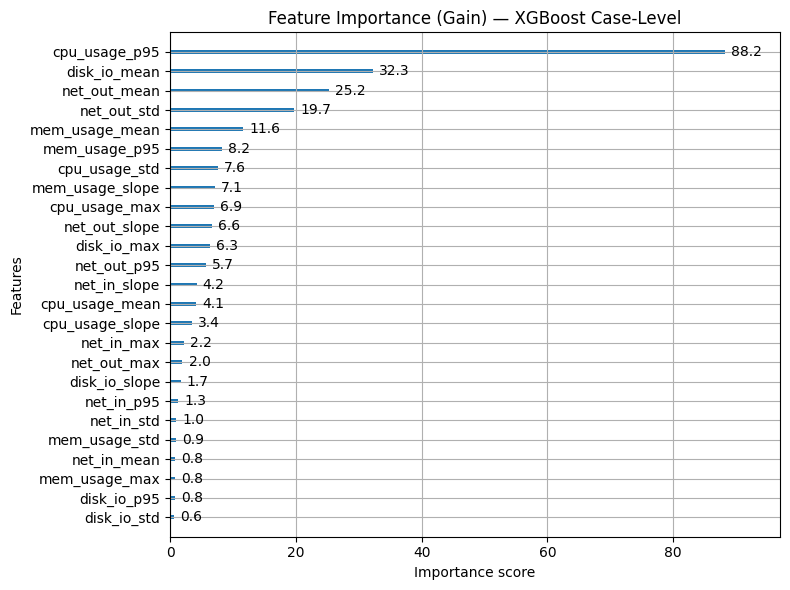

✓ feature_importance_baseline.png gespeichert


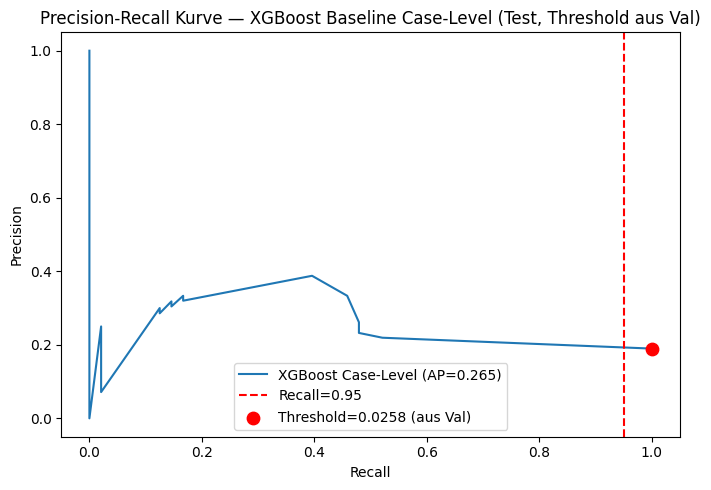

✓ pr_curve_baseline.png gespeichert


In [9]:
# ─── Plots ─────────────────────────────────────────────────────────────────────

# Feature Importance
fig, ax = plt.subplots(figsize=(8, 6))
plot_importance(
    model, ax=ax, importance_type='gain',
    title='Feature Importance (Gain) — XGBoost Case-Level',
    values_format='{v:.1f}'
)
plt.tight_layout()
plt.savefig(os.path.join(docs_path, "feature_importance_baseline.png"), dpi=150)
plt.show()
print("\u2713 feature_importance_baseline.png gespeichert")

# Precision-Recall-Kurve (Testset, Threshold aus Validation)
precisions_test, recalls_test_curve, _ = precision_recall_curve(y_test, y_proba_test)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recalls_test_curve, precisions_test, label=f'XGBoost Case-Level (AP={ap_test:.3f})')
ax.axvline(x=0.95, color='red', linestyle='--', label='Recall=0.95')
ax.scatter(
    [recall_test], [prec_test],
    color='red', zorder=5, s=80,
    label=f'Threshold={best_threshold_val:.4f} (aus Val)'
)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Kurve — XGBoost Baseline Case-Level (Test, Threshold aus Val)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(docs_path, "pr_curve_baseline.png"), dpi=150)
plt.show()
print("\u2713 pr_curve_baseline.png gespeichert")

## Ergebnis der metrischen Case-Level-Baseline (Stand C)

*Aktuelle Werte nach dem Ausführen der Zellen oben:*

| Metrik | Quelle |
|---|---|
| scale_pos_weight | Cell 3 Output |
| Best Iteration (Early Stopping) | Cell 6 Output |
| Validation-Threshold (Recall ≥ 0.95) | Cell 7 Output |
| Val-Recall_mali @ Threshold | Cell 7 Output |
| Test-AP | Cell 7 Output |
| Test-Recall_mali | Cell 7 Output |
| Test-Precision | Cell 7 Output |
| Test-F1 | Cell 7 Output |
| Test-FPR_total | Cell 7 Output |
| Test-FPR_anom | Cell 7 Output |
| Test-FPR_norm | Cell 7 Output |
| TP / FP / TN / FN | Cell 7 Output |

**Methodik:** Threshold und Early Stopping wurden ausschließlich auf dem
Validierungsset bestimmt. Das Testset wurde erst in Cell 7 berührt —
ausschließlich für die finale Evaluation. Kein Optimierungsbias gegenüber dem Testset.

**Erwartete Befunde (Stand C):**
- FPR_total bleibt voraussichtlich hoch (Case-Level max-Aggregation triggert viele Cases)
- Das ist ein dokumentierter Befund, kein Fehler: Metrics-only ist schwach, Log-Kontext (NB03) reduziert FP
- Falls Fusion ≈ Log-only: metric_trigger feuert zu häufig → Log-Kontext trägt Hauptlast

**Artefakte für NB03/NB04:**
- `docs/split_assignments.csv` → NB03 liest Split-Zuweisung
- `docs/metric_case_test_scores.csv` → NB04 Fusion
- `docs/metric_case_val_scores.csv` → NB04 Soft-Fusion Threshold